In [2]:
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA

import pmdarima as pm #auto arima
import scipy.io as sio
import os
from pathlib import Path
import warnings


## Data Loading

In [20]:
base_path = (
    "/Users/jiangruitong/Library/CloudStorage/"
    "GoogleDrive-ruitongj@andrew.cmu.edu/Shared drives/"
    "NML_NHP/Cynos PVT Data/Session Info/{subject}/Additional Performance Data"
)
# Helpers function
def _parse_filename(fname:str)-> dict:
    """
    Parse the filename to extract file_month,file_day, session, subject_initial
    Return None on parse failure
    """
    stem = Path(fname).stem
    parts = stem.split("_")
    if len(parts) !=4:
        warnings.warn(f"Unexpected filename format(expected 4 parts): {fname}")
        return None
    return {
        'file_month': parts[0],
        'file_day': int(parts[1]),
        'session': parts[2],
        'subject_initial': parts[3]
    }
def _read_session_csv(filepath:str) -> tuple[pd.DataFrame,dict]:
    """
    Read a single PVT session CSV file and return a trial-level DataFrame
    Row 0 contains both the session summary fields and the first trial RT
    Rows 1 to N contain the remaining trial RTs (summary fields are empty)
    The key RT column is 'Correct Response Latency_Duration'
    """
    df = pd.read_csv(filepath)
    # Extract session-level metadata from row 0
    session_meta = {
        'datetime_str': df['Date/Time'].iloc[0],
        'session_time_s': df['Summary - Session Time'].iloc[0],
        'n_correct':df['Summary - Correct Trials'].iloc[0],
        'n_omitted':df['Summary - Omitted Trials'].iloc[0],
        'n_missed':df['Summary - Missed Trials'].iloc[0],
        'n_iti_touches':df['Summary - ITI Touches'].iloc[0]
    }
    rt = df['Correct Response Latency_Duration'].values
    trials = pd.DataFrame({
        'trial_num':np.arange(1, len(rt)+1),
        'rt': rt
    })
    return trials, session_meta

# Main compilation function
def compile_pvt_data(subjects:list[str]) -> tuple[dict[str,pd.DataFrame],dict[str,pd.DataFrame]]:
    """
    Compile PVT data for the given list of subjects.
    Input: subjects - list of subject names

    Returns:
    trials_dict: dict[str,pd.DataFrame]
        One row per trial. Columns: subject, date, session, trial_num, rt
    
        session_dict: dict[str,pd.DataFrame]
        One row per session. Columns: subject, date, session, n_correct, n_omitted, n_missed,n_iti_touches
    """
    trials_dict = {}
    sessions_dict={}
    for subj in subjects:
        folder = base_path.format(subject=subj)
        if not os.path.isdir(folder):
            warnings.warn(f"Folder not found, skipping:{folder}")
            continue
        csv_files = sorted(f for f in os.listdir(folder) if f.endswith('.csv'))
        if not csv_files:
            warnings.warn(f"No CSV files found in {folder}")
            continue
        print(f"[{subj}] Found {len(csv_files)} session files.")
        subj_trials = []
        subj_sessions = []
    
        for fname in csv_files:
            fpath = os.path.join(folder, fname)
            finfo = _parse_filename(fname)
            if finfo is None:
                continue
            try:
                trials,meta = _read_session_csv(fpath)
            except Exception as e:
                warnings.warn(f"Failed to read {fpath}: {e}")
                continue
        # Derive date fields from CSV's Date/Time column
            dt = pd.to_datetime(
                meta['datetime_str'], format='%d/%m/%Y %H:%M:%S',errors='coerce'
            )
            date_fields = {
                'date':dt.date() if pd.notna(dt) else None,
                'month': dt.month if pd.notna(dt) else None
            }
        # Trial rows
            trials['subject'] = subj
            trials['date']=date_fields['date']
            trials['session']=finfo['session']
            subj_trials.append(trials)
        # Session row
            subj_sessions.append({
                'subject':subj,
                'date':date_fields['date'],
                'session':finfo['session'],
                'n_correct':meta['n_correct'],
                'n_omitted':meta['n_omitted'],
                'n_missed':meta['n_missed'],
                'n_iti_touches':meta['n_iti_touches']
            })
        if not subj_trials:
            warnings.warn(f"No valid data for {subj}")
            continue

        # Assemble and order columns
        df_trials = pd.concat(subj_trials, ignore_index=True)
        df_trials = df_trials[['subject','date','session','rt']]
        df_sessions = pd.DataFrame(subj_sessions)
        df_sessions = df_sessions[['subject','date','session',
                                   'n_correct','n_omitted','n_missed','n_iti_touches']]
        trials_dict[subj]=df_trials
        sessions_dict[subj]=df_sessions
        print(f"-> {len(df_trials)} trials, {len(df_sessions)} sessions")
    return trials_dict, sessions_dict

trials,sessions = compile_pvt_data(['Virgil','Baldface','Goku','Beans'])
df_v_rt = trials['Virgil']
df_g_rt = trials['Goku']
df_bf_rt = trials['Baldface']
df_b_rt = trials['Beans']
    

[Virgil] Found 180 session files.
-> 33161 trials, 180 sessions
[Baldface] Found 201 session files.
-> 29339 trials, 201 sessions
[Goku] Found 198 session files.
-> 25568 trials, 198 sessions
[Beans] Found 189 session files.
-> 25117 trials, 189 sessions


In [24]:
df_v_sessions = sessions['Virgil']
df_g_sessions = sessions['Goku']
df_bf_sessions = sessions['Baldface']
# save the compiled dataframes to csv for future use
datafolder = '/Users/jiangruitong/Library/CloudStorage/GoogleDrive-ruitongj@andrew.cmu.edu/Shared drives/NML_shared/PapersInPrep/Journals/Larry/Temporal Correlations and Performance Fluctuation'
df_v_sessions.to_csv(os.path.join(datafolder,'Virgil_sessions.csv'),index=False)
df_g_sessions.to_csv(os.path.join(datafolder,'Goku_sessions.csv'),index=False)
df_bf_sessions.to_csv(os.path.join(datafolder,'Baldface_sessions.csv'),index=False)

## Generate a summary of the reaction time data

===Descriptive stats===
               n  n_too_short  n_too_long    min     q1  median     q3    max  \
session                                                                         
Afternoon  10533          166          74  0.101  0.633   0.699  0.797  3.948   
Morning    11078          137          65  0.101  0.651   0.726  0.837  3.996   
Noon       10893          132          83  0.101  0.652   0.726  0.830  3.996   

             iqr  
session           
Afternoon  0.164  
Morning    0.186  
Noon       0.178  

===Shapiro-Wilk normality test===
 Afternoon:W=0.6016,p=1.827e-93 (non-normal)
 Morning:W=0.6467,p=7.04e-92 (non-normal)
 Noon:W=0.6228,p=5.199e-93 (non-normal)

===Kruskal-Wallis (non-normal groups)===
 H=132.3141, p=1.855e-29

===Post-hoc: Dunn's test===
              Afternoon       Morning          Noon
Afternoon  1.000000e+00  8.011292e-24  2.997958e-22
Morning    8.011292e-24  1.000000e+00  1.000000e+00
Noon       2.997958e-22  1.000000e+00  1.000000e+00


/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10533.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11078.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10893.
  res = hypotest_fun_out(*samples, **kwds)


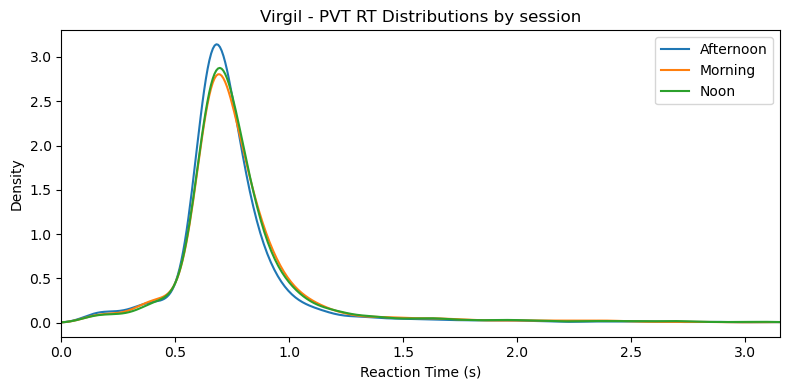

In [4]:
import importlib
import pvt_eda
importlib.reload(pvt_eda)
from pvt_eda import pvt_eda
Virgil_stats = pvt_eda(df_v_rt)

===Descriptive stats===
               n  n_too_short  n_too_long    min     q1  median     q3    max  \
session                                                                         
Afternoon   9824          159          71  0.101  0.641   0.704  0.802  3.948   
Morning    10328          131          62  0.101  0.659   0.730  0.852  3.996   
Noon       10332          128          81  0.101  0.658   0.729  0.833  3.996   

             iqr  
session           
Afternoon  0.161  
Morning    0.193  
Noon       0.175  

===Shapiro-Wilk normality test===
 Afternoon:W=0.6050,p=1.68e-91 (non-normal)
 Morning:W=0.6494,p=5.971e-90 (non-normal)
 Noon:W=0.6259,p=1.753e-91 (non-normal)

===Kruskal-Wallis (non-normal groups)===
 H=136.8140, p=1.955e-30

===Post-hoc: Dunn's test===
              Afternoon       Morning          Noon
Afternoon  1.000000e+00  1.458397e-26  1.108796e-20
Morning    1.458397e-26  1.000000e+00  5.355800e-01
Noon       1.108796e-20  5.355800e-01  1.000000e+00


/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9824.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10328.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10332.
  res = hypotest_fun_out(*samples, **kwds)


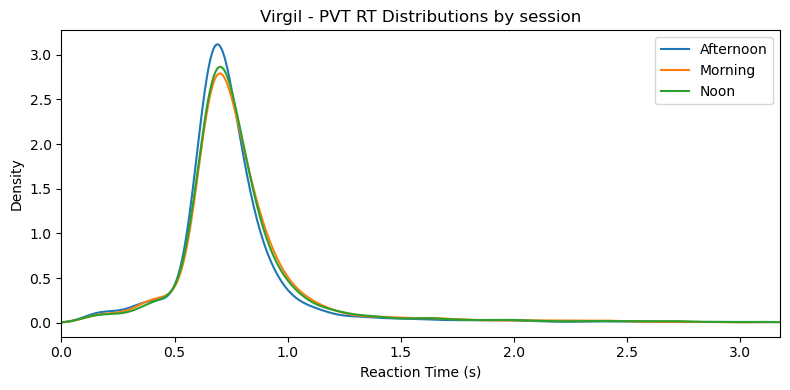

In [26]:
from datetime import date
df_v_rt_mj = df_v_rt[df_v_rt['date'].between(date(2023,3,1), date(2023,6,30))]
Virgil_stats_mj = pvt_eda(df_v_rt_mj)

===Descriptive stats===
              n  n_too_short  n_too_long    min     q1  median     q3    max  \
session                                                                        
Afternoon  5237          296          58  0.101  0.509   0.623  0.762  3.962   
Morning    7947          440          94  0.101  0.529   0.656  0.899  3.989   
Noon       6238          321          51  0.101  0.523   0.633  0.826  3.999   

             iqr  
session           
Afternoon  0.253  
Morning    0.370  
Noon       0.303  

===Shapiro-Wilk normality test===
 Afternoon:W=0.7236,p=7.209e-69 (non-normal)
 Morning:W=0.7700,p=2.309e-74 (non-normal)
 Noon:W=0.7281,p=2.075e-72 (non-normal)

===Kruskal-Wallis (non-normal groups)===
 H=100.0768, p=1.856e-22

===Post-hoc: Dunn's test===
              Afternoon       Morning          Noon
Afternoon  1.000000e+00  4.916330e-23  2.865821e-07
Morning    4.916330e-23  1.000000e+00  1.247774e-05
Noon       2.865821e-07  1.247774e-05  1.000000e+00


/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5237.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7947.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6238.
  res = hypotest_fun_out(*samples, **kwds)


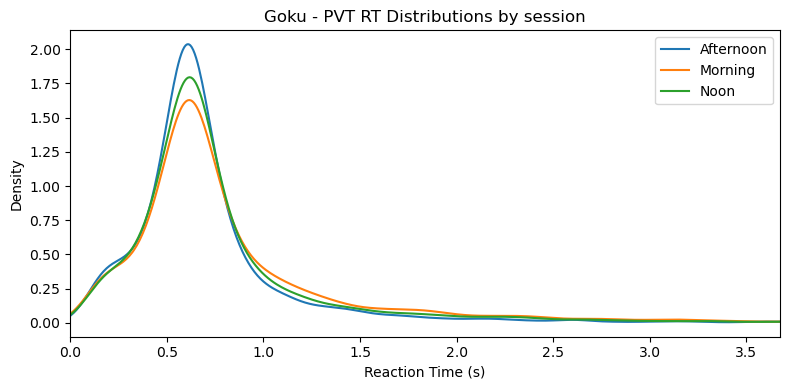

In [27]:
df_g_rt_mj = df_g_rt[df_g_rt['date'].between(date(2023,3,1), date(2023,6,30))]
Goku_stats_mj = pvt_eda(df_g_rt_mj)

===Descriptive stats===
              n  n_too_short  n_too_long    min       q1  median       q3  \
session                                                                     
Afternoon  7227          636         174  0.101  0.36600   0.439  0.59600   
Morning    8384          727          86  0.101  0.40075   0.591  0.79825   
Noon       7653          632         140  0.101  0.36900   0.455  0.66200   

             max     iqr  
session                   
Afternoon  3.982  0.2300  
Morning    3.993  0.3975  
Noon       3.995  0.2930  

===Shapiro-Wilk normality test===
 Afternoon:W=0.5919,p=1.277e-84 (non-normal)
 Morning:W=0.7847,p=3.656e-74 (non-normal)
 Noon:W=0.6656,p=1.433e-81 (non-normal)

===Kruskal-Wallis (non-normal groups)===
 H=681.6517, p=9.577e-149

===Post-hoc: Dunn's test===
               Afternoon        Morning          Noon
Afternoon   1.000000e+00  9.806242e-130  1.317762e-05
Morning    9.806242e-130   1.000000e+00  1.608379e-87
Noon        1.317762e-05   1.6083

/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7227.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8384.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7653.
  res = hypotest_fun_out(*samples, **kwds)


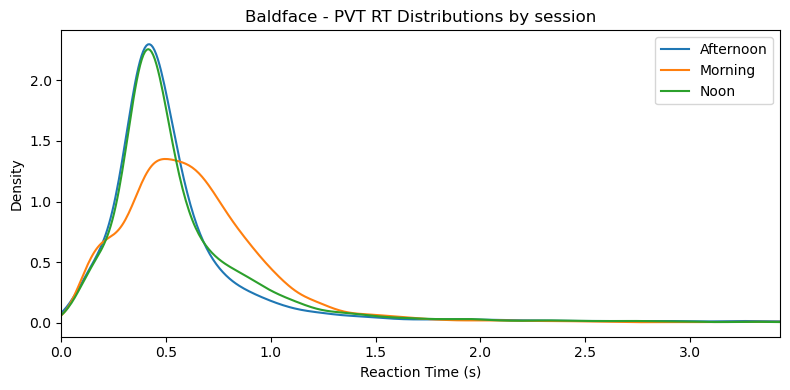

In [28]:
df_bf_rt_mj = df_bf_rt[df_bf_rt['date'].between(date(2023,3,1), date(2023,6,30))]
Baldface_stats_mj = pvt_eda(df_bf_rt_mj)

===Descriptive stats===
              n  n_too_short  n_too_long    min       q1  median     q3  \
session                                                                   
Afternoon  6322          473          68  0.101  0.47000   0.600  0.754   
Morning    9608          666         113  0.101  0.49600   0.631  0.862   
Noon       7746          503          69  0.101  0.48925   0.627  0.798   

             max      iqr  
session                    
Afternoon  3.972  0.28400  
Morning    3.989  0.36600  
Noon       3.999  0.30875  

===Shapiro-Wilk normality test===
 Afternoon:W=0.7268,p=8.154e-73 (non-normal)
 Morning:W=0.7696,p=1.015e-78 (non-normal)
 Noon:W=0.7351,p=8.883e-77 (non-normal)

===Kruskal-Wallis (non-normal groups)===
 H=97.0732, p=8.333e-22

===Post-hoc: Dunn's test===
              Afternoon       Morning          Noon
Afternoon  1.000000e+00  2.051045e-22  1.465031e-08
Morning    2.051045e-22  1.000000e+00  2.325451e-04
Noon       1.465031e-08  2.325451e-04  1.00000

/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6322.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9608.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7746.
  res = hypotest_fun_out(*samples, **kwds)


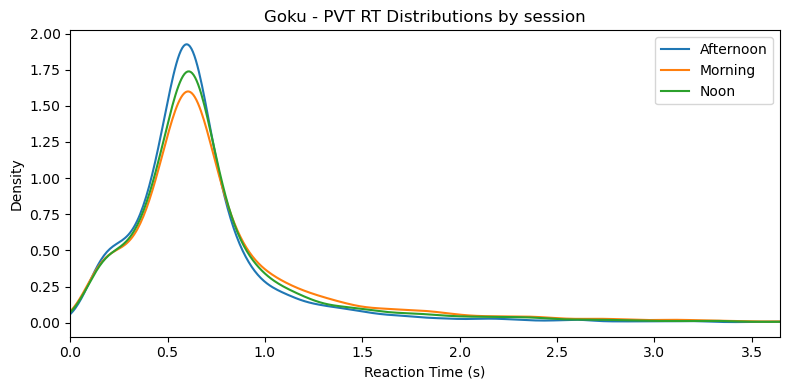

In [5]:
Goku_stats = pvt_eda(df_g_rt)

===Descriptive stats===
              n  n_too_short  n_too_long    min     q1  median     q3    max  \
session                                                                        
Afternoon  8309          704         243  0.101  0.364   0.432  0.588  3.982   
Morning    9571          774         144  0.101  0.387   0.553  0.780  3.993   
Noon       8709          689         196  0.101  0.365   0.434  0.634  3.995   

             iqr  
session           
Afternoon  0.224  
Morning    0.393  
Noon       0.269  

===Shapiro-Wilk normality test===
 Afternoon:W=0.5847,p=1.801e-88 (non-normal)
 Morning:W=0.7526,p=3.401e-80 (non-normal)
 Noon:W=0.6401,p=2.401e-86 (non-normal)

===Kruskal-Wallis (non-normal groups)===
 H=557.4813, p=8.8e-122

===Post-hoc: Dunn's test===
               Afternoon        Morning          Noon
Afternoon   1.000000e+00  1.558937e-103  2.685336e-03
Morning    1.558937e-103   1.000000e+00  7.622928e-76
Noon        2.685336e-03   7.622928e-76  1.000000e+00


/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8309.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9571.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/empatica_gui/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8709.
  res = hypotest_fun_out(*samples, **kwds)


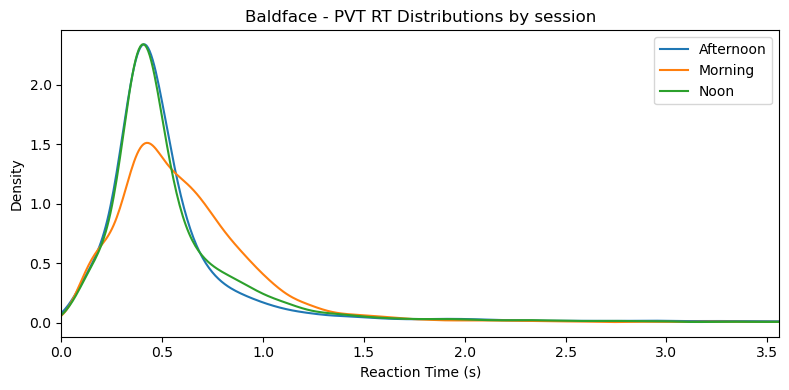

In [6]:
Baldface_stats = pvt_eda(df_bf_rt)

In [14]:
# save the reaction time dataframe into .csv files
reaction_time_output_folder = "/Users/jiangruitong/Library/CloudStorage/GoogleDrive-ruitongj@andrew.cmu.edu/Shared drives/NML_shared/PapersInPrep/Journals/Larry/Temporal Correlations and Performance Fluctuation"
df_v_rt.to_csv(os.path.join(reaction_time_output_folder,'Virgil_reaction_time.csv'), index=False)
df_g_rt.to_csv(os.path.join(reaction_time_output_folder,'Goku_reaction_time.csv'), index=False)
df_bf_rt.to_csv(os.path.join(reaction_time_output_folder,'Baldface_reaction_time.csv'), index=False)

In [ ]:
# Save the session level summary dataframe into .csv files


## Mixed effect model to see whether there's session level effect or not

In [13]:
from datetime import date
import statsmodels.formula.api as smf
# combine the reaction time dataframes into one dataframe for all subjects
df_all_rt = pd.concat([df_v_rt, df_g_rt, df_bf_rt], ignore_index=True)
# filter the reaction time data to only include data from March to June
df_all_rt = df_all_rt[df_all_rt['date'].between(date(2023,3,1), date(2023,6,30))]
df_all_rt['month'] = pd.to_datetime(df_all_rt['date']).dt.month

# aggrgate to daily level first
daily = df_all_rt.groupby(['subject','date','session','month']).agg(
    median_rt=('rt','median')
).reset_index()
daily['median_rt_ms']=daily['median_rt']*1000
# Median RT model
md1 = smf.mixedlm(
    "median_rt_ms~C(session,Treatment('Morning'))*C(month,Treatment(3))",
    daily,groups = daily["subject"],
    re_formula="~1"
)
print(md1.fit(reml=True).summary())

                                          Mixed Linear Model Regression Results
Model:                                  MixedLM                      Dependent Variable:                      median_rt_ms
No. Observations:                       495                          Method:                                  REML        
No. Groups:                             3                            Scale:                                   16767.5863  
Min. group size:                        162                          Log-Likelihood:                          -3061.3221  
Max. group size:                        168                          Converged:                               Yes         
Mean group size:                        165.0                                                                             
--------------------------------------------------------------------------------------------------------------------------
                                                           

Generate visualization of mixed effect model

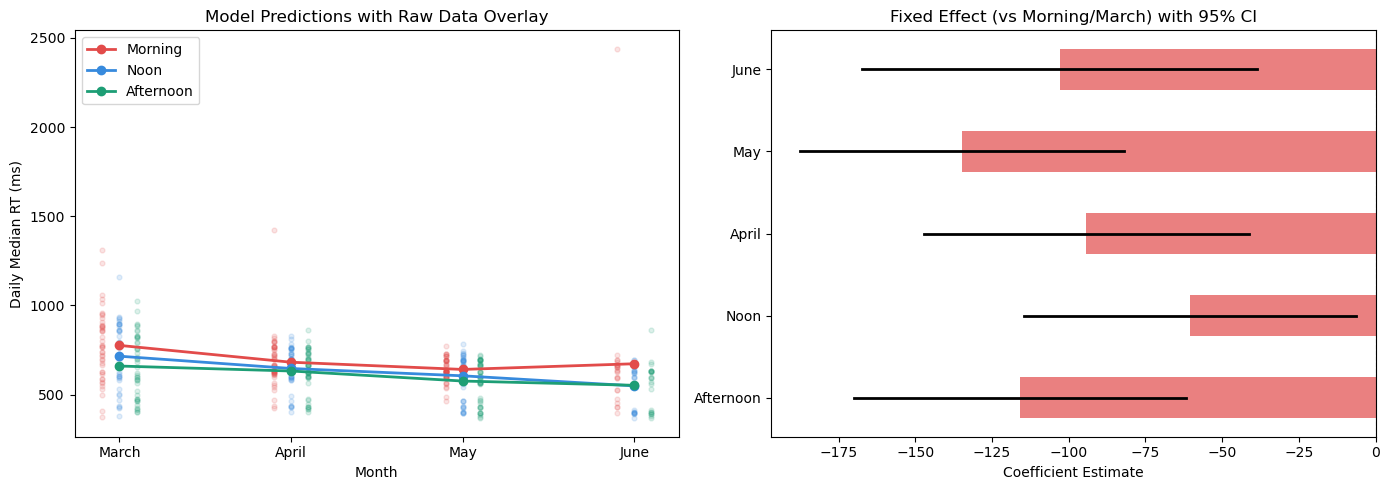

In [15]:
# Panel 1: Model predictions (session x month) with raw data
fig,axes = plt.subplots(1,2,figsize=(14,5))
sessions = ['Morning','Noon','Afternoon']
months = [3,4,5,6]
month_labels = ['March','April','May','June']
colors = {'Morning':'#E24B4A','Noon':'#378ADD','Afternoon':'#1D9E75'}

# Extract fixed effects from the model
result = md1.fit(reml=True)
pred_grid = pd.DataFrame([
    {'session': s, 'month': m} for s in sessions for m in months
])

# Build predictions manually from coefficients
coefs = result.fe_params
for _,row in pred_grid.iterrows():
    val = coefs['Intercept']
    s,m=row['session'],row['month']
    if s != 'Morning':
        val += coefs[f"C(session, Treatment('Morning'))[T.{s}]"]
    if m != 3:
        val += coefs[f"C(month, Treatment(3))[T.{m}]"]
    if s != 'Morning' and m != 3:
        val += coefs[f"C(session, Treatment('Morning'))[T.{s}]:C(month, Treatment(3))[T.{m}]"]
    pred_grid.loc[(pred_grid['session']==s)&(pred_grid['month']==m),'predicted'] = val

# Left panel: predictions + raw data
ax = axes[0]
for sess in sessions:
    sub = pred_grid[pred_grid['session']==sess]
    ax.plot(sub['month'],sub['predicted'],'-o',color=colors[sess],
            label=sess,linewidth=2,markersize=6,zorder=3)
    # overlay raw daily data as jittered points
    jitter = {'Morning':-0.1,'Noon':0,'Afternoon':0.1}[sess]
    raw = daily[daily['session']==sess]
    ax.scatter(raw['month']+jitter,raw['median_rt_ms'],
               color=colors[sess],alpha=0.15,s=12,zorder=1)
ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Daily Median RT (ms)')
ax.set_title('Model Predictions with Raw Data Overlay')
ax.legend()

# Right panel: fixed effect coefficients with CI
ax2 = axes[1]
terms = [
    ("Afternoon","C(session, Treatment('Morning'))[T.Afternoon]"),
    ("Noon","C(session, Treatment('Morning'))[T.Noon]"),
    ("April","C(month, Treatment(3))[T.4]"),
    ("May","C(month, Treatment(3))[T.5]"),
    ("June","C(month, Treatment(3))[T.6]")
]
conf = result.conf_int()
y_pos = np.arange(len(terms))
for i, (label,term) in enumerate(terms):
    coef = result.fe_params[term]
    ci_low,ci_high = conf.loc[term]
    color='#E24B4A' if coef < 0 else '#378ADD'
    ax2.barh(i,coef,color=color,alpha=0.7,height=0.5)
    ax2.plot([ci_low,ci_high],[i,i],'k-',linewidth=2)
ax2.axvline(0,color='grey',linestyle='--',linewidth=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([t[0] for t in terms])
ax2.set_xlabel('Coefficient Estimate')
ax2.set_title('Fixed Effect (vs Morning/March) with 95% CI')
plt.tight_layout()
#plt.savefig('mixed_model_results.png',dpi=600)
plt.show()

In [11]:
print(result.fe_params.index.tolist())

['Intercept', "C(session, Treatment('Morning'))[T.Afternoon]", "C(session, Treatment('Morning'))[T.Noon]", 'C(month, Treatment(3))[T.4]', 'C(month, Treatment(3))[T.5]', 'C(month, Treatment(3))[T.6]', "C(session, Treatment('Morning'))[T.Afternoon]:C(month, Treatment(3))[T.4]", "C(session, Treatment('Morning'))[T.Noon]:C(month, Treatment(3))[T.4]", "C(session, Treatment('Morning'))[T.Afternoon]:C(month, Treatment(3))[T.5]", "C(session, Treatment('Morning'))[T.Noon]:C(month, Treatment(3))[T.5]", "C(session, Treatment('Morning'))[T.Afternoon]:C(month, Treatment(3))[T.6]", "C(session, Treatment('Morning'))[T.Noon]:C(month, Treatment(3))[T.6]"]
